<a href="https://colab.research.google.com/github/mukterpotom76/EES_lab-mukter/blob/main/mukterlab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip -q install -U geemap

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Packages imported successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.9 MB/s eta 0:00:00
Packages imported successfully.


In [2]:
PROJECT_ID = 'ess322-lab1'

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

print('Earth Engine initialised.')

Earth Engine initialised.


In [11]:
CENTER_LON = 95.33
CENTER_LAT = 28.07

centre = ee.Geometry.Point([CENTER_LON, CENTER_LAT])

aoi = centre.buffer(10_000).bounds()

sample_point = centre

print('AOI created.')

AOI created.


In [12]:
START_DATE = '2025-01-01'
END_DATE   = '2026-01-01'

MAX_CLOUD = 60  # scene-level cloud cover percentage

raw_collection = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt('CLOUD_COVER', MAX_CLOUD))
)

scene_count = raw_collection.size().getInfo()

print('Number of matching scenes:', scene_count)

if scene_count == 0:
    raise ValueError(
        'No scenes found. Increase the date range or MAX_CLOUD.'
    )

Number of matching scenes: 38


In [13]:
def preprocess_landsat8(image):
    # QA_PIXEL bits used here:
    # bit 1 = dilated cloud
    # bit 2 = cirrus
    # bit 3 = cloud
    # bit 4 = cloud shadow
    # bit 5 = snow
    qa = image.select('QA_PIXEL')

    clear_mask = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
        .And(qa.bitwiseAnd(1 << 5).eq(0))
    )

    # Keep pixels that are not radiometrically saturated.
    saturation_mask = image.select('QA_RADSAT').eq(0)

    # Apply official Collection 2 scaling to optical surface-reflectance bands.
    optical = image.select('SR_B[1-7]').multiply(0.0000275).add(-0.2)

    return (
        image.addBands(optical, None, True)
        .updateMask(clear_mask)
        .updateMask(saturation_mask)
    )

# Choose the least-cloudy matching scene, then preprocess it.
raw_image = ee.Image(raw_collection.sort('CLOUD_COVER').first())
image = preprocess_landsat8(raw_image)

print('Product ID:', raw_image.get('LANDSAT_PRODUCT_ID').getInfo())
print('Acquisition date:', raw_image.date().format('YYYY-MM-dd').getInfo())
print('Scene cloud cover (%):', raw_image.get('CLOUD_COVER').getInfo())


Product ID: LC08_L2SP_134041_20251118_20251202_02_T1
Acquisition date: 2025-11-18
Scene cloud cover (%): 0.44


In [17]:
# Select the reflectance bands once for clarity.
green = image.select("SR_B3")
red = image.select("SR_B4")
nir = image.select("SR_B5")
swir2 = image.select("SR_B7")

# NDVI
ndvi = image.expression(
    "(NIR - RED) / (NIR + RED)",
    {"NIR": nir, "RED": red}
).rename("NDVI")

# McFeeters NDWI
ndwi = image.expression(
    "(GREEN - NIR) / (GREEN + NIR)",
    {"GREEN": green, "NIR": nir}
).rename("NDWI")

# SAVI
L = 0.5
savi = image.expression(
    "((NIR - RED) / (NIR + RED + L)) * (1 + L)",
    {"NIR": nir, "RED": red, "L": L}
).rename("SAVI")

# NBR
nbr = image.expression(
    "(NIR - SWIR2) / (NIR + SWIR2)",
    {"NIR": nir, "SWIR2": swir2}
).rename("NBR")

index_image = image.addBands([ndvi, ndwi, savi, nbr])

print("Index bands added:")
print(index_image.bandNames().getInfo())

Index bands added:
['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'NDVI', 'NDWI', 'SAVI', 'NBR']


In [18]:
Map = geemap.Map()
Map.centerObject(aoi, 10)

true_color = {
    "bands": ["SR_B4", "SR_B3", "SR_B2"],
    "min": 0.0,
    "max": 0.30
}

false_color = {
    "bands": ["SR_B5", "SR_B4", "SR_B3"],
    "min": 0.0,
    "max": 0.35
}

Map.addLayer(
    image.clip(aoi),
    true_color,
    "True colour (4-3-2)",
    True
)

Map.addLayer(
    image.clip(aoi),
    false_color,
    "False colour (5-4-3)",
    False
)

Map.addLayer(
    ndvi.clip(aoi),
    {
        "min": -1,
        "max": 1,
        "palette": ["8c510a", "f6e8c3", "01665e"]
    },
    "NDVI",
    False
)

Map.addLayer(
    ndwi.clip(aoi),
    {
        "min": -1,
        "max": 1,
        "palette": ["a6611a", "f5f5f5", "018571"]
    },
    "NDWI (McFeeters)",
    False
)

Map.addLayer(
    savi.clip(aoi),
    {
        "min": -1,
        "max": 1,
        "palette": ["8c510a", "f6e8c3", "01665e"]
    },
    "SAVI",
    False
)

Map.addLayer(
    nbr.clip(aoi),
    {
        "min": -1,
        "max": 1,
        "palette": ["b2182b", "f7f7f7", "2166ac"]
    },
    "NBR",
    False
)

Map.addLayer(
    aoi,
    {"color": "black"},
    "AOI",
    False
)

Map

Map(center=[28.07000456106417, 95.33017018509675], controls=(WidgetControl(options=['position', 'transparent_b…

In [20]:
indices= index_image.select(["NDVI", "NDWI", "SAVI", "NBR"])

stats= indices.reduceRegion(
    reducer= (
        ee.Reducer.mean()
        .combine(ee.Reducer.stdDev(), None, True)
        .combine(ee.Reducer.min(), None, True)
        .combine(ee.Reducer.max(), None, True)
    ),
    geometry= aoi,
    scale= 30,
    maxPixels= 1e10,
    bestEffort= True
)

stats_dict= stats.getInfo()

summary_rows= []
for name in ["NDVI", "NDWI", "SAVI", "NBR"]:
    summary_rows.append({
        "index": name,
        "mean": stats_dict[f"{name}_mean"],
        "stdDev": stats_dict[f"{name}_stdDev"],
        "min": stats_dict[f"{name}_min"],
        "max": stats_dict[f"{name}_max"]
    })

summary_df= pd.DataFrame(summary_rows)
summary_df


,index,mean,stdDev,min,max
0,NDVI,0.617671,0.412929,-1.838632,1.193320
1,NDWI,-0.569159,0.377939,-0.913680,1.566638
2,SAVI,0.403338,0.214834,-0.223829,0.812600
3,NBR,0.516380,8.938333,-964.333333,1115.400000


In [24]:
sample_fc= indices.sample(
    region= aoi,
    scale= 30,
    numPixels= 2500,
    seed= 42,
    geometries= False,
    tileScale= 2,
)
sample_info= sample_fc.getInfo()

sample_df= pd.DataFrame(
    [feature["properties"]for feature in sample_info["features"]]
).dropna()

print("Number of sampled clear pixels:", len(sample_df))
sample_df.head()


Number of sampled clear pixels: 2020


,NBR,NDVI,NDWI,SAVI
0,0.710976,0.893978,-0.816903,0.592190
1,0.692853,0.879937,-0.791546,0.588147
2,0.392418,0.663548,-0.591703,0.427551
3,0.142469,0.422013,-0.424827,0.219046
4,0.661499,0.831377,-0.730601,0.510167


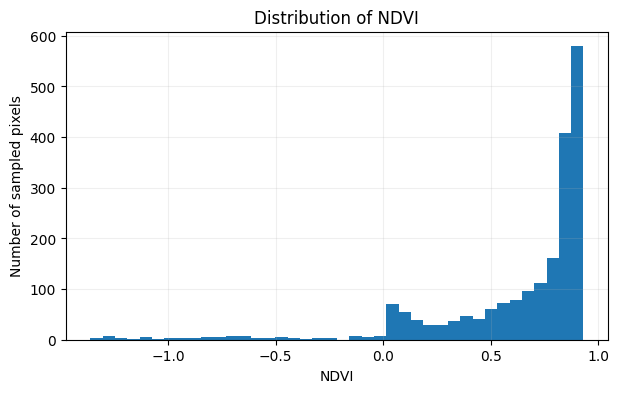

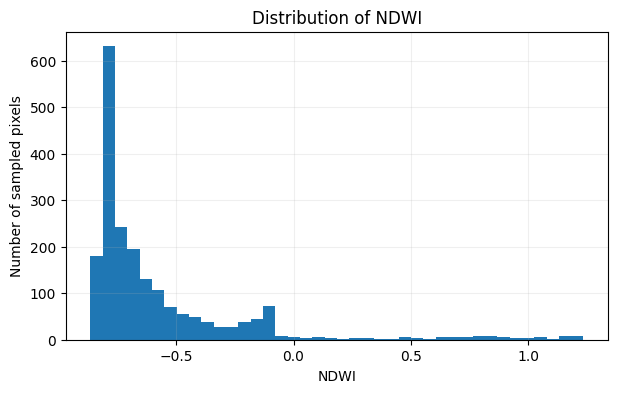

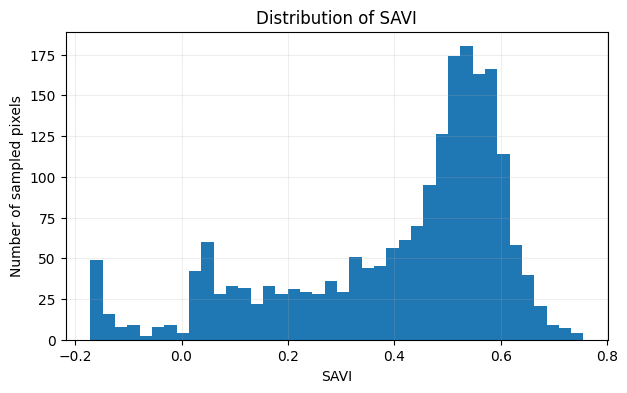

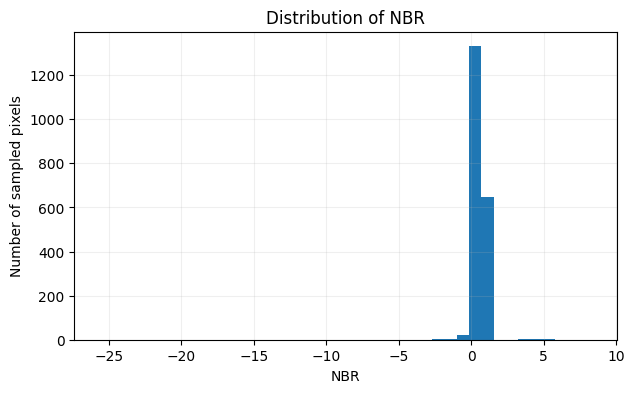

In [26]:
for name in ["NDVI", "NDWI", "SAVI", "NBR"]:
    plt.figure(figsize=(7, 4))
    plt.hist(sample_df[name], bins=40)
    plt.xlabel(name)
    plt.ylabel("Number of sampled pixels")
    plt.title(f"Distribution of {name}")
    plt.grid(alpha=0.2)
    plt.show()

In [28]:
sample_df["NDVI_minus_SAVI"]= sample_df["NDVI"] - sample_df["SAVI"]

comparison= sample_df[["NDVI", "SAVI", "NDVI_minus_SAVI"]].describe()


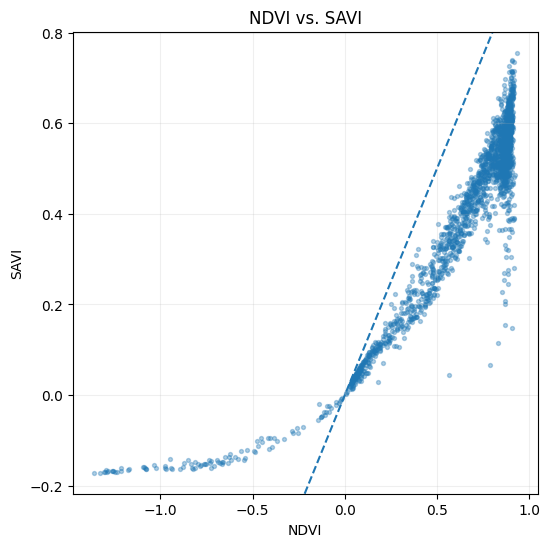

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(sample_df["NDVI"], sample_df["SAVI"], s=8, alpha=0.35)
plt.xlabel("NDVI")
plt.ylabel("SAVI")
plt.title("NDVI vs. SAVI")
plt.axline((0, 0), slope=1, linestyle="--")
plt.grid(alpha=0.2)
plt.show()

In [34]:
vegetation_candidate= ndvi.gt(0.40).rename("vegetation_candidate")
water_candidate= ndwi.gt(0.00).rename("water_candidate")

MaskMap= geemap.Map()
MaskMap.centerObject(aoi, 10)
MaskMap.addLayer(image.clip(aoi), true_color, "True colour", True)
MaskMap.addLayer(
    vegetation_candidate.selfMask().clip(aoi),
    {"palette": ["00AA00"]},
    "NDVI > 0.40",
    False
)
MaskMap.addLayer(
    water_candidate.selfMask().clip(aoi),
    {"palette": "0000FF"},
    "NDVI > 0.00",
    False,
)
MaskMap


Map(center=[28.07000456106417, 95.33017018509675], controls=(WidgetControl(options=['position', 'transparent_b…

In [35]:
export_indices = index_image.select(
    ["NDVI","NDWI","SAVI","NBR"]).clip(aoi)

task = ee.batch.Export.image.toDrive(
    image=export_indices,
    description="Landsat8_spectral_Indices",
    folder="EarthEngine",
    fileNamePrefix="Landsat8_NDVI_NDWI_SAVI_NBR",
    region=aoi,
    scale=30,
    maxPixels=1e9,
    fileFormat="GeoTIFF",
)

task.start()
print("Export prepared. Uncomment task.start() to submit it.")


Export prepared. Uncomment task.start() to submit it.
